# Plotting template banks

Here we plot the template banks sizes, in particular generating and Figure 3

In [1]:
import h5py
import numpy as np

In [2]:
def get_bank_size(bank_filename):
    try:
        with h5py.File(bank_filename, 'r') as bank_f:
            return bank_f['mass1'].size
    except FileNotFoundError:
        return None

In [3]:
estimated_bank_format = "output/lisa_ew_{days_before_merger}_day.hdf"
days_before = [0.5, 1, 4, 7, 14]

bank_size_estimated = {0.5: 27593, 1: 28270, 4: 26242, 7: 14051, 14: 6861}
# The above is previous results - we will use them if the bank can't be found (this is for consistency in the data release, so we don't have to have all the bank files in the repo)
for day_before in days_before:
    bank_size_est = get_bank_size(estimated_bank_format.format(days_before_merger=day_before))
    if bank_size_est is not None:
        bank_size_estimated[day_before] = bank_size_est

print(bank_size_estimated)

{0.5: 27593, 1: 28270, 4: 26242, 7: 14051, 14: 6861}


In [4]:
withgb_bank_format = "output/lisa_ew_model_{days_before_merger}_day.hdf"
days_before = [0.5, 1, 4, 7, 14]

bank_size_withgb = {0.5: 14274, 1: 24912, 4: 17713, 7: 14237, 14: 6828}
# The above is previous results - we will use them if the bank can't be found (this is for consistency in the data release, so we don't have to have all the bank files in the repo)
for day_before in days_before:
    withgb_size = get_bank_size(withgb_bank_format.format(days_before_merger=day_before))
    if withgb_size is not None:
        bank_size_withgb[day_before] = withgb_size

print(bank_size_withgb)

{0.5: 14274, 1: 24912, 4: 17713, 7: 14237, 14: 6828}


In [5]:
previous_bank_format = "../../datasets/lisa_ew_{days_before_merger}_day_optimistic.hdf"
bank_size_previous ={0.5: 6416, 1: 7997, 4: 7923, 7: 5580, 14: 3262}
# The above is previous results - we will use them if the bank can't be found (this is for consistency in the data release, so we don't have to have all the bank files in the repo)
for day_before in days_before:
    previous_size = get_bank_size(previous_bank_format.format(days_before_merger=day_before))
    if previous_size is not None:
        bank_size_previous[day_before] = previous_size

print(bank_size_previous)

{0.5: 6416, 1: 7997, 4: 7923, 7: 5580, 14: 3262}


In [6]:
max_factor = 0
min_factor = np.inf
for day_before in days_before:
    n_previous= bank_size_previous[day_before]
    n_withgb = bank_size_withgb[day_before]
    n_estimated = bank_size_estimated[day_before]

    max_factor = max(max_factor, n_withgb / n_previous)
    min_factor = min(min_factor, n_withgb / n_previous)
    max_factor = max(max_factor, n_estimated / n_previous)
    min_factor = min(min_factor, n_estimated / n_previous)

Previous iterations of the paper had this as a table, but the plot seems to be nicer, but the code is kept here for info

In [7]:
def to_str(size_int):
    if not np.isnan(size_int):
        return f"{size_int:,d}"
    else:
        return '--'

In [8]:
tabular_str = """\\begin{tabular}{|c|ccc|}
\\hline
Time before Merger & \multicolumn{3}{c|}{Number of Templates} \\\\
\\cline{2-4}
(days) & Model, no GBs & Model with GBs & Estimated \\\\
\\hline
"""
for day_before in days_before:
    tabular_str += f"{day_before} & {to_str(bank_size_previous[day_before])} & {to_str(bank_size_withgb[day_before])} & {to_str(bank_size_estimated[day_before])}  \\\\\n"
tabular_str += """\\hline
\end{tabular}
"""



In [9]:
table_str = f"""
\\begin{{table}}[h]
\\begin{{centering}}
{tabular_str}
\\caption{{Template Bank sizes assuming different \\acp{{PSD}}.
The inclusion of \\acp{{GB}} in the PSD increases the bank size by a factor of between {min_factor:.1f} and {max_factor:.1f}
\\label{{tab:bank_size}}
}}
\\end{{centering}}
\\end{{table}}
"""

print(table_str)
# with open('../../paper/tables/bank_size.tex', 'w') as bank_table_f:
#     bank_table_f.write(table_str)


\begin{table}[h]
\begin{centering}
\begin{tabular}{|c|ccc|}
\hline
Time before Merger & \multicolumn{3}{c|}{Number of Templates} \\
\cline{2-4}
(days) & Model, no GBs & Model with GBs & Estimated \\
\hline
0.5 & 6,416 & 14,274 & 27,593  \\
1 & 7,997 & 24,912 & 28,270  \\
4 & 7,923 & 17,713 & 26,242  \\
7 & 5,580 & 14,237 & 14,051  \\
14 & 3,262 & 6,828 & 6,861  \\
\hline
\end{tabular}

\caption{Template Bank sizes assuming different \acp{PSD}.
The inclusion of \acp{GB} in the PSD increases the bank size by a factor of between 2.1 and 4.3
\label{tab:bank_size}
}
\end{centering}
\end{table}



In [10]:
from matplotlib import pyplot as plt

# Use the style file defined in the repository root
plt.style.use('../../paper.mplstyle')



In [11]:


previous_line = np.zeros(len(days_before))
model_line = np.zeros(len(days_before))
estimate_line = np.zeros(len(days_before))
# Make lines from each of the dictionary values
for i, day_before in enumerate(days_before):
    previous_line[i] = bank_size_previous[day_before]
    model_line[i] = bank_size_withgb[day_before]
    estimate_line[i] = bank_size_estimated[day_before]

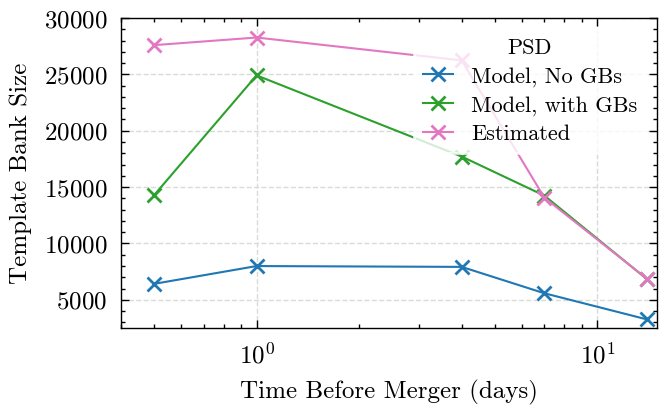

In [ ]:
fig, ax = plt.subplots(1)

ax.plot(days_before, previous_line, marker='x', color='tab:blue', label='Model, No GBs')
ax.plot(days_before, model_line, marker='x', color='tab:green', label='Model, with GBs')
ax.plot(days_before, estimate_line, marker='x', color='tab:pink', label='Estimated')
ax.set_xscale('log')
ax.grid()
ax.set_xlabel('Time Before Merger (days)')
ax.set_ylabel('Template Bank Size')
ax.set_xlim(0.4, 15)
ax.set_ylim(2500, 30000)
ax.legend(loc='upper right', title='PSD')
fig.savefig('../../paper/images/figure_3_bank_size.pdf')


In [13]:
# These are the numbers which are input into the caption for the above figure

max_factor_model = 0
min_factor_model = np.inf
max_factor_estimate = 0
min_factor_estimate = np.inf
for day_before in days_before:
    n_previous= bank_size_previous[day_before]
    n_withgb = bank_size_withgb[day_before]
    n_estimated = bank_size_estimated[day_before]

    max_factor_model = max(max_factor_model, n_withgb / n_previous)
    min_factor_model = min(min_factor_model, n_withgb / n_previous)
    max_factor_estimate = max(max_factor_estimate, n_estimated / n_withgb)
    min_factor_estimate = min(min_factor_estimate, n_estimated / n_withgb)

print(f'Inclusion of unresolvable GBs in the model increases bank size by a factor between {min_factor_model:.1f} and {max_factor_model:.1f}')
print(f'Using the estimated rather than modelled PSD increases bank size by a factor between {min_factor_estimate:.1f} and {max_factor_estimate:.1f}')

Inclusion of unresolvable GBs in the model increases bank size by a factor between 2.1 and 3.1
Using the estimated rather than modelled PSD increases bank size by a factor between 1.0 and 1.9
